# B18 — Entanglement and Bell States

**Track B — the SDK.** Everything here has a Track A ancestor; the new thing is
that Qiskit will now *measure* entanglement for us instead of only detecting it.

---

## The one-sentence version

Two entangled qubits are a system where **the whole is completely determined and
the parts are completely undetermined**.

That sentence should feel wrong. Everywhere else in physics — and everywhere in
classical information — knowing everything about a system means knowing
everything about its pieces. A Bell state breaks that. Ask it "what is the pair
doing?" and the answer is exact: a single pure state, zero uncertainty. Ask it
"what is qubit 0 doing?" and the honest answer is *nothing is known* — a fair
coin, maximally mixed, a Bloch vector of length zero.

The centrepiece of this notebook is one figure that turns that from a slogan into
a dial you can watch. We take a one-parameter family of states

$$|\psi(t)\rangle = \cos t\,|00\rangle + \sin t\,|11\rangle, \qquad t \in [0, \pi/2],$$

and plot three quantities against the same $t$: the **von Neumann entropy** of
one qubit's reduced state, the **concurrence** of the pair, and the **length of
each qubit's Bloch vector**. The first two rise together. The third falls to
exactly zero. Entanglement is not something added on top of the qubits — it is
paid for out of what the individual qubits know about themselves.

## Where we are

| Track A (by hand) | Qiskit |
|---|---|
| reshape to $2\times2$, `np.linalg.svd` | `schmidt_decomposition` |
| $\rho = |\psi\rangle\langle\psi|$ as an outer product | `DensityMatrix` |
| summing over the other qubit's index | `partial_trace` |
| $-\sum \lambda_i \log_2 \lambda_i$ | `entropy` |
| (A06 had no measure at all — only a rank test) | `concurrence` |

A06 could only answer **yes/no**: Schmidt rank 1 means product, rank 2 means
entangled. That is a blunt instrument — it calls a barely-correlated state and a
Bell state by the same name. The dial below is what fixes it.

## What we build

1. The four **Bell states** as the image of the computational basis under one
   fixed circuit — so they are a *basis*, not four unrelated party tricks.
2. `partial_trace` and `DensityMatrix`, checked against a from-scratch partial
   trace written out index by index.
3. **The dial**: entropy, concurrence and Bloch length on one shared axis.
4. **Correlations**: separately random, together perfectly correlated — and the
   detail most treatments skip, that $\langle ZZ\rangle$ correlation is free but
   $\langle XX\rangle$ correlation is exactly what costs entanglement.
5. The **Schmidt decomposition**, which is where the entropy number comes from.
6. **Honest limits**, and they are severe: reduced entropy is a valid
   entanglement measure *only* for pure global states, and we build a state that
   scores a perfect 1.000 bit while containing no entanglement whatsoever.

In [1]:
from qviz import backends, bloch, grid, style

import matplotlib.pyplot as plt
import numpy as np
import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ClassicalRegister, QuantumRegister
from qiskit.quantum_info import (DensityMatrix, Pauli, Statevector, concurrence,
                                 entropy, partial_trace, schmidt_decomposition)

style.use()

SEED = backends.seed_for("B18")
rng = np.random.default_rng(SEED)
print("qiskit", qiskit.__version__, " seed", SEED)

qiskit 2.5.1  seed 20260822


## The four Bell states are one circuit, four inputs

Most introductions present the Bell states as a list to memorise:

$$|\Phi^\pm\rangle = \tfrac{1}{\sqrt2}\big(|00\rangle \pm |11\rangle\big), \qquad
|\Psi^\pm\rangle = \tfrac{1}{\sqrt2}\big(|10\rangle \pm |01\rangle\big).$$

They are much easier to hold onto as **one circuit applied to the four
computational basis states**. Prepare $|b_1 b_0\rangle$ with X gates, then run
`h(0); cx(0, 1)`. That is the whole construction:

| input | output |
|---|---|
| $|00\rangle$ | $|\Phi^+\rangle$ |
| $|01\rangle$ | $|\Phi^-\rangle$ |
| $|10\rangle$ | $|\Psi^+\rangle$ |
| $|11\rangle$ | $|\Psi^-\rangle$ |

Because the circuit is unitary and the inputs are an orthonormal basis, the
outputs are an orthonormal basis too — the **Bell basis**. Every two-qubit state
can be expanded in it, which is exactly what teleportation and superdense coding
(B25) exploit: a *measurement* in this basis is a physically meaningful thing to
do.

Watch the endianness, because it decides which state is which. Qubit 0 is the
**rightmost** label character, so `x(0)` on $|00\rangle$ gives $|01\rangle$, and
`cx(0, 1)` means "control qubit 0, target qubit 1". A big-endian textbook writes
the same four states with the bits the other way round; $|\Psi^\pm\rangle$ looks
identical either way, and $|\Phi^-\rangle$ vs $|\Psi^-\rangle$ is where you get
burned.

In [2]:
def bell_circuit(b1, b0):
    """One circuit, four inputs. Input |b1 b0> comes out a Bell state."""
    qc = QuantumCircuit(2)
    if b0:
        qc.x(0)          # qubit 0 is the RIGHTMOST label character
    if b1:
        qc.x(1)
    qc.h(0)
    qc.cx(0, 1)          # control qubit 0, target qubit 1
    return qc


inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]
names = [r"$|\Phi^+\rangle$", r"$|\Phi^-\rangle$",
         r"$|\Psi^+\rangle$", r"$|\Psi^-\rangle$"]
plain = ["Phi+", "Phi-", "Psi+", "Psi-"]

BELL = {key: Statevector(bell_circuit(*key)) for key in inputs}

for nm, key in zip(plain, inputs):
    print(f"input |{key[0]}{key[1]}>  ->  {nm:<5}",
          np.round(BELL[key].data.real, 4))

# The four outputs form an orthonormal basis: stack them as columns.
B = np.column_stack([BELL[k].data for k in inputs])
print("\nBell basis is unitary (orthonormal columns):",
      np.allclose(B.conj().T @ B, np.eye(4)))

input |00>  ->  Phi+  [0.7071 0.     0.     0.7071]
input |01>  ->  Phi-  [ 0.7071  0.      0.     -0.7071]
input |10>  ->  Psi+  [0.     0.7071 0.7071 0.    ]
input |11>  ->  Psi-  [ 0.     -0.7071  0.7071  0.    ]

Bell basis is unitary (orthonormal columns): True


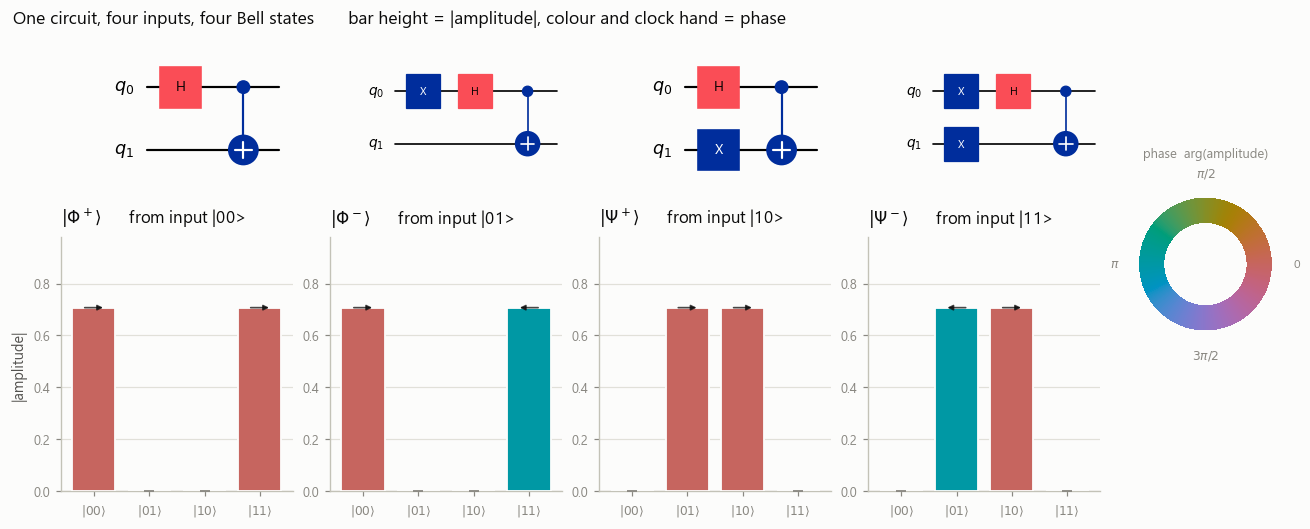

In [3]:
fig = plt.figure(figsize=(11.8, 4.7))
gs = fig.add_gridspec(2, 5, width_ratios=[1, 1, 1, 1, 0.60],
                      height_ratios=[0.80, 1.35])

# The circuit drawer keeps its own aspect ratio, so per-panel titles on the top
# row would sit at four different heights. Name each state on the bar panel
# underneath instead, where the baseline is shared.
for k, (name, key) in enumerate(zip(names, inputs)):
    axc = fig.add_subplot(gs[0, k])
    bell_circuit(*key).draw("mpl", ax=axc,
                            style={"backgroundcolor": style.SURFACE})

    axb = fig.add_subplot(gs[1, k])
    grid.amp_bars(axb, BELL[key].data, ylim=0.98, label_rotation=0)
    axb.set_title(f"{name}      from input |{key[0]}{key[1]}>", loc="left",
                  fontsize=11)
    if k:
        axb.set_ylabel("")

axw = fig.add_subplot(gs[:, 4], projection="polar")
style.phase_wheel(axw)

fig.suptitle("One circuit, four inputs, four Bell states       "
             "bar height = |amplitude|, colour and clock hand = phase",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

Read the bottom row as a pair of facts. **Which two bars are lit** separates
$\Phi$ from $\Psi$: $\Phi$ puts its weight on the states where the qubits agree,
$\Psi$ on the states where they disagree. **The colour of the second bar**
separates $+$ from $-$: a half-turn of hue, and a clock hand pointing the
opposite way, is a factor of $-1$.

That relative sign is invisible to any measurement in the computational basis —
all four states give 50/50 over two outcomes — and completely visible in the
$|\pm\rangle$ basis. Same lesson as A06's CZ figure, and it is the raw material
of B19's CHSH test.

## `partial_trace`: how to ask about one qubit

A two-qubit state does not generally contain a "state of qubit 0" in the
statevector sense. What it contains is a **density matrix** for qubit 0, obtained
by *tracing out* qubit 1:

$$\rho_0 = \mathrm{Tr}_1\,|\psi\rangle\langle\psi|, \qquad
(\rho_0)_{ab} = \sum_{e} \psi_{ae}\,\overline{\psi_{be}}.$$

In words: line up the two indices you are keeping and sum over every value of the
index you are discarding. It is the quantum version of marginalising a joint
probability distribution, and it is the *only* correct way to answer "what would
I see if I only ever touched qubit 0".

Qiskit spells it `partial_trace(state, qargs)`, where **`qargs` is the list of
qubits to throw away**, not the ones to keep. Getting that backwards is a
one-character bug that produces a perfectly plausible wrong answer, so below we
write the sum out by hand and check the two agree.

In [4]:
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)


def _merge(kept_i, env_i, keep, traced):
    """Rebuild a full little-endian index from a kept index and an environment
    index. Bit `slot` of `kept_i` belongs to qubit `keep[slot]`."""
    i = 0
    for slot, q in enumerate(keep):
        i |= ((kept_i >> slot) & 1) << q
    for slot, q in enumerate(traced):
        i |= ((env_i >> slot) & 1) << q
    return i


def my_partial_trace(rho, keep, n=2):
    """Trace out every qubit not in `keep`, written index by index.

    Little-endian throughout: qubit q owns bit q of the index. The kept
    subsystem preserves the qubits' relative order, which is the convention
    qiskit.quantum_info.partial_trace uses.
    """
    keep = sorted(keep)
    traced = [q for q in range(n) if q not in keep]
    out = np.zeros((2 ** len(keep), 2 ** len(keep)), dtype=complex)
    for a in range(out.shape[0]):
        for b in range(out.shape[0]):
            for e in range(2 ** len(traced)):
                out[a, b] += rho[_merge(a, e, keep, traced),
                                 _merge(b, e, keep, traced)]
    return out


def bloch_vector(rho):
    """r = (Tr(rho X), Tr(rho Y), Tr(rho Z)). Length 1 = pure, 0 = nothing known."""
    return np.array([float(np.real(np.trace(np.asarray(rho) @ P)))
                     for P in (X, Y, Z)])


phi_plus = BELL[(0, 0)]
rho = DensityMatrix(phi_plus)                 # |psi><psi|, built by Qiskit
rho_hand = np.outer(phi_plus.data, phi_plus.data.conj())
print("DensityMatrix == outer product:", np.allclose(rho.data, rho_hand))

rho0 = partial_trace(phi_plus, [1])           # [1] = the qubit thrown AWAY
rho1 = partial_trace(phi_plus, [0])
print("my partial trace == qiskit's  :",
      np.allclose(my_partial_trace(rho_hand, keep=[0]), rho0.data),
      np.allclose(my_partial_trace(rho_hand, keep=[1]), rho1.data))

print("\nrho (the pair):\n", np.round(rho.data.real, 3))
print("\nrho_0 (qubit 0 alone):\n", np.round(rho0.data.real, 3))
print("\npurity     pair", round(float(rho.purity().real), 4),
      "  qubit0", round(float(rho0.purity().real), 4),
      "  qubit1", round(float(rho1.purity().real), 4))
print("entropy    pair", round(entropy(rho), 4),
      "  qubit0", round(entropy(rho0), 4),
      "  qubit1", round(entropy(rho1), 4), " (bits)")
print("Bloch |r|  pair  n/a",
      "  qubit0", round(float(np.linalg.norm(bloch_vector(rho0.data))), 4),
      "  qubit1", round(float(np.linalg.norm(bloch_vector(rho1.data))), 4),
      " (a 2-qubit state has no single Bloch vector)")

DensityMatrix == outer product: True
my partial trace == qiskit's  : True True

rho (the pair):
 [[0.5 0.  0.  0.5]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.5 0.  0.  0.5]]

rho_0 (qubit 0 alone):
 [[0.5 0. ]
 [0.  0.5]]

purity     pair 1.0   qubit0 0.5   qubit1 0.5


entropy    pair 0.0   qubit0 1.0   qubit1 1.0  (bits)
Bloch |r|  pair  n/a   qubit0 0.0   qubit1 0.0  (a 2-qubit state has no single Bloch vector)


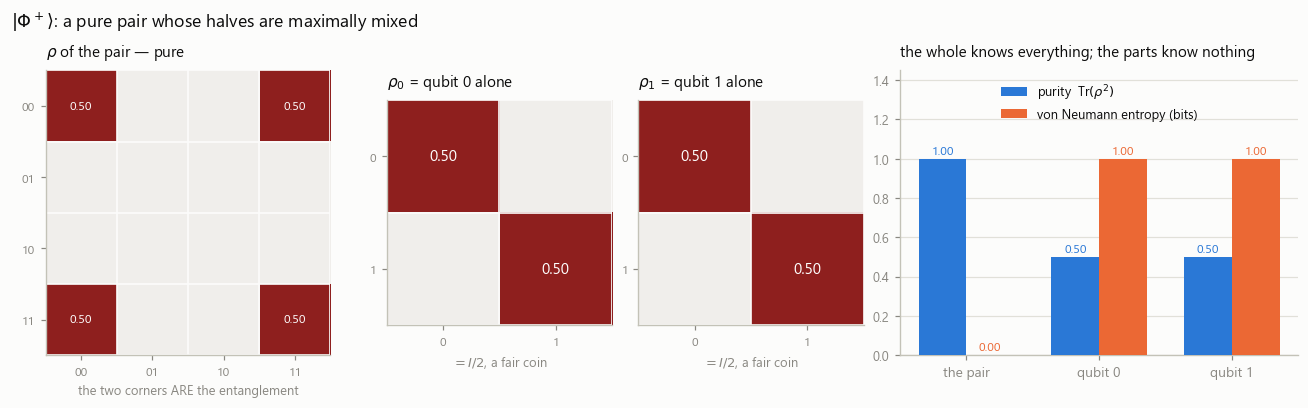

In [5]:
fig = plt.figure(figsize=(11.8, 3.6))
gs = fig.add_gridspec(1, 4, width_ratios=[1.3, 0.85, 0.85, 1.5])

ax0 = fig.add_subplot(gs[0, 0])
grid.matrix(ax0, rho.data, part="re", cbar=False, annot_size=8,
            title=r"$\rho$ of the pair — pure")
ax0.set_xlabel("the two corners ARE the entanglement", fontsize=8.5,
               color=style.MUTED)

for ax_i, rr, lab in [
        (fig.add_subplot(gs[0, 1]), rho0.data, r"$\rho_0$ = qubit 0 alone"),
        (fig.add_subplot(gs[0, 2]), rho1.data, r"$\rho_1$ = qubit 1 alone")]:
    grid.matrix(ax_i, rr, part="re", cbar=False, annot_size=10,
                labels=["0", "1"], title=lab, vmax=0.5)
    ax_i.set_xlabel("$= I/2$, a fair coin", fontsize=8.5, color=style.MUTED)

axb = fig.add_subplot(gs[0, 3])
w = 0.36
pur = [float(rho.purity().real), float(rho0.purity().real),
       float(rho1.purity().real)]
ent = [entropy(rho), entropy(rho0), entropy(rho1)]
xs = np.arange(3)
axb.bar(xs - w / 2, pur, width=w, color=style.BLUE,
        label=r"purity  Tr$(\rho^2)$", zorder=3)
axb.bar(xs + w / 2, ent, width=w, color=style.ORANGE,
        label="von Neumann entropy (bits)", zorder=3)
axb.set_xticks(xs)
axb.set_xticklabels(["the pair", "qubit 0", "qubit 1"], fontsize=9)
axb.set_ylim(0, 1.45)
axb.set_axisbelow(True)
axb.legend(loc="upper center", ncols=1, fontsize=8.5)
axb.set_title("the whole knows everything; the parts know nothing",
              loc="left", fontsize=10)
for x, v, c in list(zip(xs - w / 2, pur, [style.BLUE] * 3)) + \
               list(zip(xs + w / 2, ent, [style.ORANGE] * 3)):
    axb.text(x, v + 0.025, f"{v:.2f}", ha="center", fontsize=8, color=c)

fig.suptitle(r"$|\Phi^+\rangle$: a pure pair whose halves are maximally mixed",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

The right-hand panel is the paradox in six bars. The **pair** has purity 1 and
entropy 0 — a pure state, complete knowledge, nothing left to learn. Each
**qubit** has purity $\tfrac12$, the floor for a single qubit, and entropy
exactly 1 bit: total ignorance.

For a classical joint distribution this is impossible. A marginal entropy can
never exceed the joint entropy, because forgetting a variable cannot make you
*less* certain. Here $S(\rho_0) = 1 > 0 = S(\rho_{01})$. That inequality failing
is arguably the cleanest formal statement of what entanglement is.

Where did the information go? Into the off-diagonal corners of the left panel.
Those two entries — $\langle 00|\rho|11\rangle$ and its conjugate — are the whole
difference between an entangled state and a coin that was flipped in advance.
Keep an eye on them: the last figure in this notebook deletes them and changes
nothing else.

## The dial

Now turn a knob. Define

$$|\psi(t)\rangle = \cos t\,|00\rangle + \sin t\,|11\rangle,$$

built by an honest circuit: `ry(2t, 0)` puts qubit 0 into
$\cos t\,|0\rangle + \sin t\,|1\rangle$, then `cx(0, 1)` copies that value into
qubit 1. At $t=0$ it is $|00\rangle$, a product state. At $t=\pi/4$ it is
$|\Phi^+\rangle$. At $t=\pi/2$ it is $|11\rangle$, product again.

Three quantities, all computed by Qiskit, all on one shared $x$-axis:

- **Entropy** $S(\rho_0) = -\mathrm{Tr}\,\rho_0\log_2\rho_0$ — the entanglement
  entropy, in bits. It is the amount of information about qubit 0 that is
  *unavailable* to someone holding only qubit 0.
- **Concurrence** $C$ — a purpose-built two-qubit entanglement measure, 0 for
  product states and 1 for a Bell state. For this family $C = |\sin 2t|$.
- **Bloch-vector length** $|\vec r_0|$, $|\vec r_1|$ — how far each qubit's
  reduced state sits from the centre of the Bloch ball. 1 = a definite pure
  state; 0 = nothing known at all.

The claim being tested: as the first two rise, the third must fall. Not "tends
to fall" — for pure states it obeys an exact identity,

$$|\vec r\,|^2 + C^2 = 1,$$

which the right-hand panel plots as a quarter circle.

In [6]:
def dial_circuit(t):
    """cos(t)|00> + sin(t)|11>, as a circuit rather than a hand-written vector."""
    qc = QuantumCircuit(2)
    qc.ry(2 * t, 0)
    qc.cx(0, 1)
    return qc


ts = np.linspace(0.0, np.pi / 2, 241)
S0 = np.empty_like(ts)
S1 = np.empty_like(ts)
C = np.empty_like(ts)
R0 = np.empty_like(ts)
R1 = np.empty_like(ts)

for i, t in enumerate(ts):
    sv = Statevector(dial_circuit(t))
    red0, red1 = partial_trace(sv, [1]), partial_trace(sv, [0])
    S0[i] = entropy(red0)                      # entropy() is base 2 -> bits
    S1[i] = entropy(red1)
    C[i] = concurrence(sv)
    R0[i] = np.linalg.norm(bloch_vector(red0.data))
    R1[i] = np.linalg.norm(bloch_vector(red1.data))

mid = int(np.argmin(np.abs(ts - np.pi / 4)))
print(f"at t = pi/4 :  S = {S0[mid]:.6f} bits   C = {C[mid]:.6f}   "
      f"|r| = {R0[mid]:.3e}")
print("max |C - |sin 2t||    :", float(np.abs(C - np.abs(np.sin(2 * ts))).max()))
print("max | |r|^2 + C^2 - 1 |:", float(np.abs(R0 ** 2 + C ** 2 - 1).max()))
print("max |S(rho_0) - S(rho_1)|:", float(np.abs(S0 - S1).max()))

at t = pi/4 :  S = 1.000000 bits   C = 1.000000   |r| = 0.000e+00
max |C - |sin 2t||    : 2.3136006999102676e-14
max | |r|^2 + C^2 - 1 |: 4.440892098500626e-16
max |S(rho_0) - S(rho_1)|: 0.0


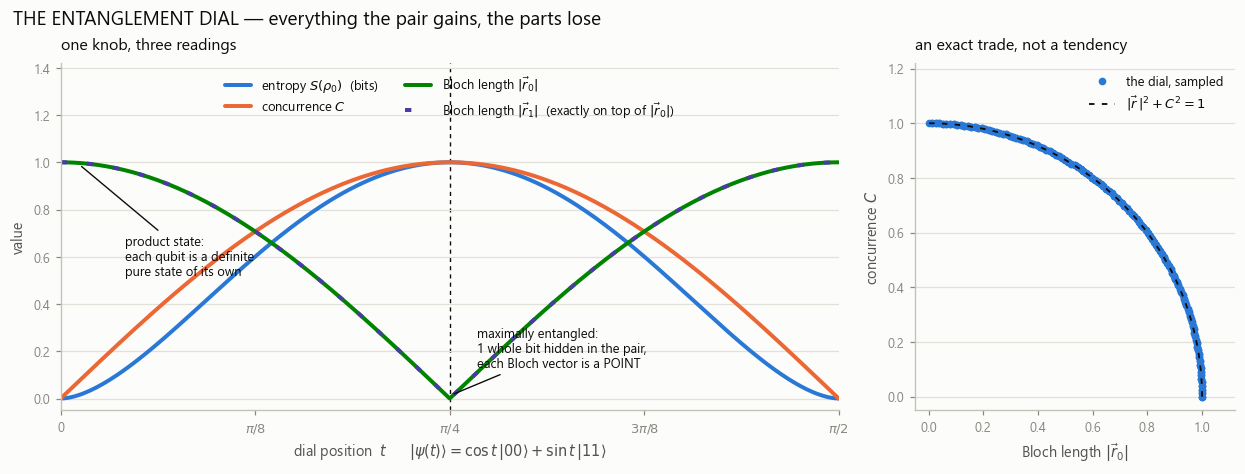

In [7]:
fig = plt.figure(figsize=(11.4, 4.2))
gs = fig.add_gridspec(1, 2, width_ratios=[2.15, 1])

ax = fig.add_subplot(gs[0, 0])
ax.plot(ts, S0, color=style.BLUE, lw=2.6,
        label=r"entropy $S(\rho_0)$  (bits)")
ax.plot(ts, C, color=style.ORANGE, lw=2.6, label=r"concurrence $C$")
ax.plot(ts, R0, color=style.GREEN, lw=2.6,
        label=r"Bloch length $|\vec r_0|$")
# r_1 lies exactly on top of r_0, so it is drawn as sparse dots over the green
# line rather than a second curve nobody can see.
ax.plot(ts, R1, color=style.VIOLET, lw=2.6, ls=(0, (1.6, 5.0)),
        label=r"Bloch length $|\vec r_1|$  (exactly on top of $|\vec r_0|$)")
ax.axvline(np.pi / 4, color=style.INK, lw=0.9, ls=(0, (3, 3)), zorder=1)

ax.set_xlim(0, np.pi / 2)
ax.set_ylim(-0.05, 1.42)
ax.set_xticks([0, np.pi / 8, np.pi / 4, 3 * np.pi / 8, np.pi / 2])
ax.set_xticklabels(["0", r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"])
ax.set_xlabel(r"dial position  $t$      "
              r"$|\psi(t)\rangle = \cos t\,|00\rangle + \sin t\,|11\rangle$")
ax.set_ylabel("value")
ax.legend(loc="upper center", ncols=2, fontsize=8.5)
ax.set_title("one knob, three readings", loc="left", fontsize=10.5)

grid.annotate(ax, "product state:\neach qubit is a definite\npure state of its own",
              xy=(0.035, 0.995), xytext=(0.13, 0.60), color=style.INK)
grid.annotate(ax, "maximally entangled:\n1 whole bit hidden in the pair,\n"
                  "each Bloch vector is a POINT",
              xy=(np.pi / 4, 0.012), xytext=(np.pi / 4 + 0.055, 0.21),
              color=style.INK)

axr = fig.add_subplot(gs[0, 1])
th = np.linspace(0, np.pi / 2, 200)
axr.scatter(R0, C, s=16, color=style.BLUE, zorder=3, label="the dial, sampled")
# The reference circle goes ON TOP: underneath, the dense scatter hides it.
axr.plot(np.cos(th), np.sin(th), color=style.INK, lw=1.2, ls=(0, (3, 4)),
         zorder=5, label=r"$|\vec r\,|^2 + C^2 = 1$")
axr.set_xlim(-0.05, 1.12)
axr.set_ylim(-0.05, 1.22)
axr.set_aspect("equal")
axr.set_xlabel(r"Bloch length $|\vec r_0|$")
axr.set_ylabel(r"concurrence $C$")
axr.legend(loc="upper right", fontsize=8.5)
axr.set_title("an exact trade, not a tendency", loc="left", fontsize=10.5)

fig.suptitle("THE ENTANGLEMENT DIAL — everything the pair gains, the parts lose",
             x=0.005, ha="left", fontsize=12.5)
plt.show()

Stare at the crossing point. At $t = \pi/4$ the blue and orange curves are both
pinned at 1 and the green one is at **exactly zero** — not small, zero. The
individual qubits have no direction left. Every single-qubit measurement you can
devise, in any basis, returns a fair coin.

And the right panel says the trade is exact. The sampled dial does not merely
trend down-and-right; it lies *on* the unit quarter-circle to machine precision.
For a pure two-qubit state there is one budget, and entanglement and local
definiteness split it between them.

The next figure is the same statement drawn on the sphere, which is where it
stops being a plot and starts being uncomfortable.

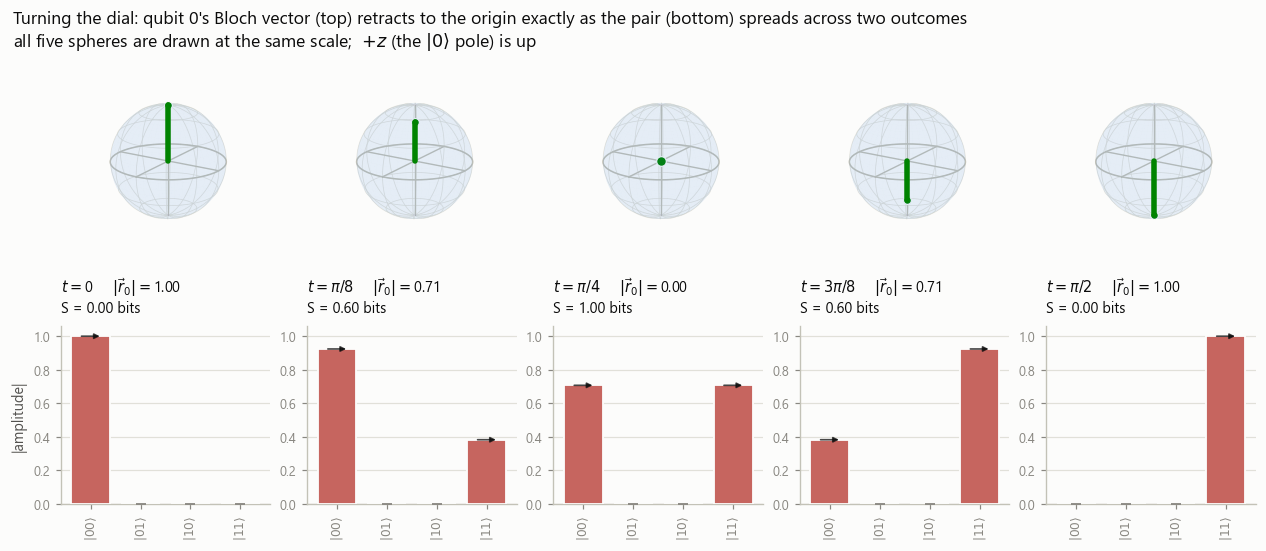

In [8]:
TS = [0.0, np.pi / 8, np.pi / 4, 3 * np.pi / 8, np.pi / 2]
TLAB = ["0", r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"]

fig = plt.figure(figsize=(11.4, 4.9))
gs = fig.add_gridspec(2, len(TS), height_ratios=[1.15, 1.0])

# Every sphere is drawn at the same zoom, so radii match on screen: this figure
# is a comparison of arrow LENGTHS and any per-panel rescaling would be a lie.
# Pole labels are dropped (the orientation is stated in the title) to buy the
# spheres the space -- with them the frame has to leave room out to r = 1.4.
for k, t in enumerate(TS):
    sv_k = Statevector(dial_circuit(t))
    r_k = bloch_vector(partial_trace(sv_k, [1]).data)

    ax3 = fig.add_subplot(gs[0, k], projection="3d")
    bloch.sphere(ax3, labels=False, zoom=1.45)
    bloch.vector(ax3, r_k, color=style.GREEN, lw=3.6)

    axb = fig.add_subplot(gs[1, k])
    grid.amp_bars(axb, sv_k.data, ylim=1.06, label_rotation=90)
    axb.set_title(f"$t = ${TLAB[k]}     " + r"$|\vec r_0| = $"
                  f"{np.linalg.norm(r_k):.2f}\n"
                  f"S = {entropy(partial_trace(sv_k, [1])):.2f} bits",
                  loc="left", fontsize=9.5)
    if k:
        axb.set_ylabel("")

fig.suptitle("Turning the dial: qubit 0's Bloch vector (top) retracts to the "
             "origin exactly as the pair (bottom) spreads across two outcomes\n"
             r"all five spheres are drawn at the same scale;  $+z$ (the "
             r"$|0\rangle$ pole) is up",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

Top row: one arrow, shrinking to a dot and then growing back out the other side.
Bottom row: the pair's amplitudes, spreading from one bar to two and back.

The two rows are the same fact told twice. There is no frame in which the arrow
is long *and* the pair is spread — and notice that the arrow never tips over or
rotates on its way in. It **retracts**. A rotation would mean qubit 0 is in some
*other* pure state; a retraction means it has stopped being in a pure state at
all. `plot_bloch_multivector` draws exactly this picture, and B14 spends a
notebook on why readers misread it: a zero-length arrow looks like a rendering
bug, and it is the physics.

## Separately random, together certain

Measure both qubits of $|\Phi^+\rangle$ in the computational basis. Two things
are true at once, and both are worth seeing rather than being told:

- **Each qubit alone is a fair coin.** Qubit 0's marginal is 50/50, and so is
  qubit 1's. This follows directly from $\rho_0 = \rho_1 = I/2$ above.
- **The two coins always agree.** `01` and `10` never occur. Not "rarely" —
  never, at any number of shots, on an ideal simulator.

We use Aer's `SamplerV2` through `qviz.backends.sampler()`, seeded. Results are
addressed by the classical register's **name**, so declaring
`ClassicalRegister(2, "c")` explicitly makes it `result[0].data.c` rather than
the `.meas` that `measure_all()` would have given us.

The top strip is the raw shot record — one column per shot, top row qubit 1,
bottom row qubit 0. Randomness you can actually see, in two rows that are
pixel-for-pixel identical.

counts: {'11': 2021, '00': 2075}
marginal qubit 0: [0.5066 0.4934]    marginal qubit 1: [0.5066 0.4934]
shots where the two qubits disagreed: 0 of 4096


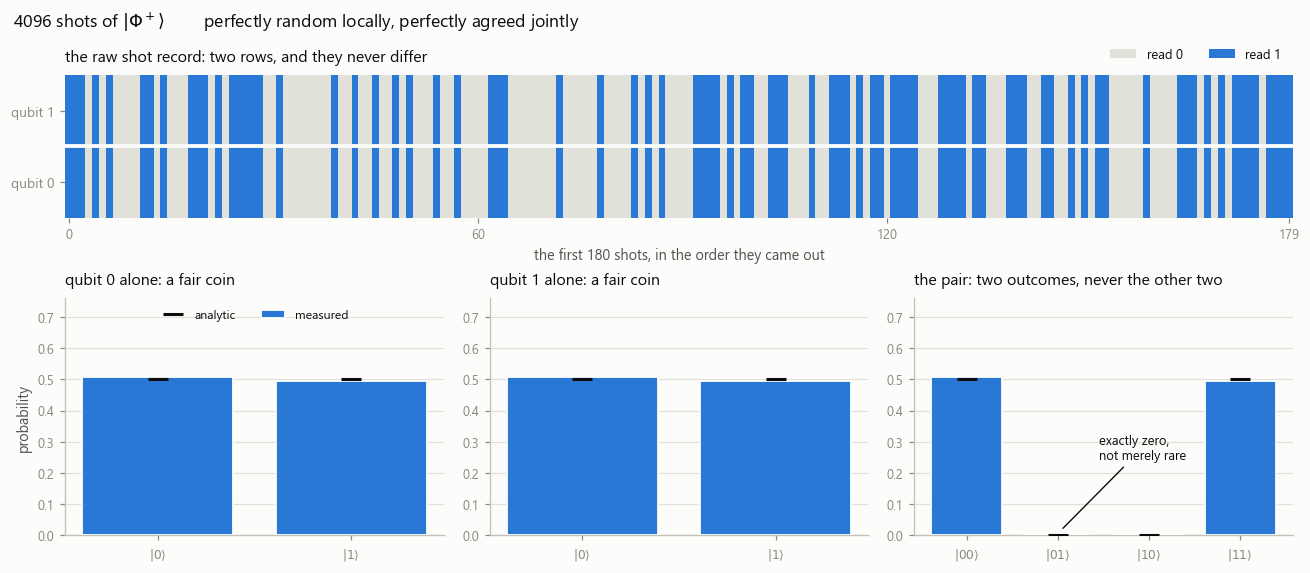

In [9]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

SHOTS = 4096
qr, cr = QuantumRegister(2, "q"), ClassicalRegister(2, "c")
qc_meas = QuantumCircuit(qr, cr)
qc_meas.h(0)
qc_meas.cx(0, 1)
qc_meas.measure([0, 1], [0, 1])

res = backends.sampler(shots=SHOTS, seed=SEED).run([qc_meas]).result()
bits = res[0].data.c                      # ".c" = the classical register's NAME
counts = bits.get_counts()
print("counts:", counts)

packed = bits.array[:, 0].astype(int)     # one byte per shot; bit q is qubit q
q0 = (packed >> 0) & 1
q1 = (packed >> 1) & 1

joint = np.array([counts.get(format(i, "02b"), 0) for i in range(4)]) / SHOTS
marg0 = np.array([float(np.mean(q0 == 0)), float(np.mean(q0 == 1))])
marg1 = np.array([float(np.mean(q1 == 0)), float(np.mean(q1 == 1))])
print("marginal qubit 0:", np.round(marg0, 4),
      "   marginal qubit 1:", np.round(marg1, 4))
print("shots where the two qubits disagreed:", int(np.sum(q0 != q1)),
      "of", SHOTS)

NSTRIP = 180
cmap01 = ListedColormap([style.GRID, style.BLUE])

fig = plt.figure(figsize=(11.8, 5.1))
gs = fig.add_gridspec(2, 3, height_ratios=[0.60, 1.0])

axs = fig.add_subplot(gs[0, :])
axs.imshow(np.vstack([q1[:NSTRIP], q0[:NSTRIP]]), cmap=cmap01, vmin=0, vmax=1,
           aspect="auto", interpolation="nearest")
axs.axhline(0.5, color=style.SURFACE, lw=2.5, zorder=4)   # separate the rows
axs.set_yticks([0, 1])
axs.set_yticklabels(["qubit 1", "qubit 0"], fontsize=9)
axs.set_xticks([0, 60, 120, NSTRIP - 1])
axs.set_xlabel(f"the first {NSTRIP} shots, in the order they came out")
axs.grid(False)
for sp in axs.spines.values():
    sp.set_visible(False)
axs.legend(handles=[Patch(facecolor=style.GRID, label="read 0"),
                    Patch(facecolor=style.BLUE, label="read 1")],
           loc="lower right", bbox_to_anchor=(1.0, 1.02), ncols=2)
axs.set_title("the raw shot record: two rows, and they never differ",
              loc="left", fontsize=10.5)

ax0 = fig.add_subplot(gs[1, 0])
grid.prob_bars(ax0, marg0, labels=["0", "1"], analytic=[0.5, 0.5],
               ymax_pad=1.5)
ax0.legend(loc="upper center", ncols=2, fontsize=8)
ax0.set_title("qubit 0 alone: a fair coin", loc="left", fontsize=10.5)

ax1 = fig.add_subplot(gs[1, 1])
grid.prob_bars(ax1, marg1, labels=["0", "1"], analytic=[0.5, 0.5],
               ymax_pad=1.5)
ax1.set_ylabel("")
ax1.set_title("qubit 1 alone: a fair coin", loc="left", fontsize=10.5)

ax2 = fig.add_subplot(gs[1, 2])
grid.prob_bars(ax2, joint, analytic=np.abs(phi_plus.data) ** 2, ymax_pad=1.5)
ax2.set_ylabel("")
ax2.set_title("the pair: two outcomes, never the other two", loc="left",
              fontsize=10.5)
grid.annotate(ax2, "exactly zero,\nnot merely rare", xy=(1.02, 0.012),
              xytext=(1.45, 0.28), color=style.INK)

fig.suptitle(f"{SHOTS} shots of " + r"$|\Phi^+\rangle$" +
             "        perfectly random locally, perfectly agreed jointly",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

### The correlation that is free, and the one that costs

Here is the part most treatments skip, and it matters enormously for B19.

Perfect agreement in the **Z basis is not evidence of entanglement.** A product
state has it: $|00\rangle$ gives $\langle ZZ\rangle = 1$ with no entanglement at
all, and so does a classical coin flipped once and copied onto two cards. Along
our entire dial, $\langle ZZ\rangle$ is pinned at 1 — including at $t=0$, where
the state is a plain product.

What entanglement buys is agreement in **more than one basis at the same time**.
$\langle XX\rangle$ tracks the concurrence exactly. And $\langle Z_0\rangle$ —
the single-qubit expectation, which is just the Bloch $z$-component — dies at
precisely the rate $\langle XX\rangle$ grows.

Three curves, and the same conservation law again.

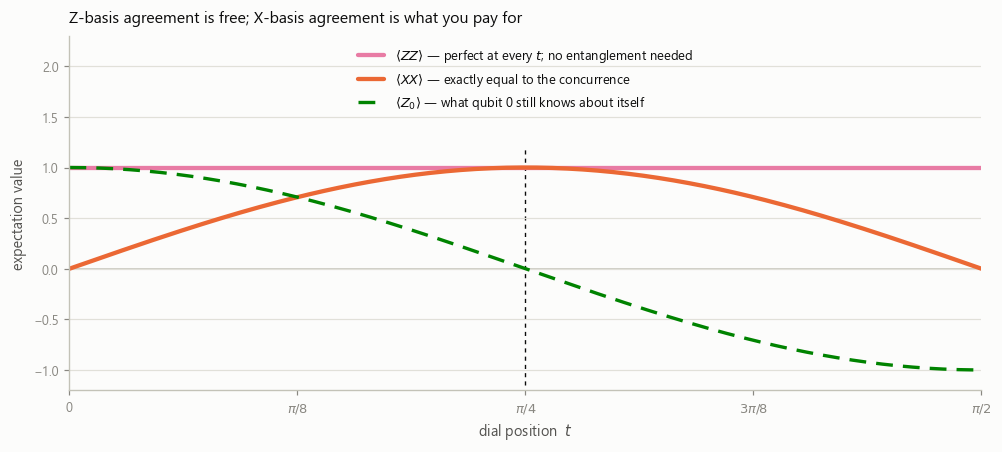

max |<XX> - concurrence| : 2.3136006999102676e-14
<ZZ> range               : 1.0 to 1.0
max |<Z_0>^2 + <XX>^2 - 1| : 4.440892098500626e-16


In [10]:
ZZ = np.empty_like(ts)
XX = np.empty_like(ts)
Z0 = np.empty_like(ts)
for i, t in enumerate(ts):
    sv = Statevector(dial_circuit(t))
    # Pauli label strings are little-endian too: "IZ" means Z on qubit 0.
    ZZ[i] = float(np.real(sv.expectation_value(Pauli("ZZ"))))
    XX[i] = float(np.real(sv.expectation_value(Pauli("XX"))))
    Z0[i] = float(np.real(sv.expectation_value(Pauli("IZ"))))

fig, ax = plt.subplots(figsize=(9.0, 4.0))
ax.plot(ts, ZZ, color=style.MAGENTA, lw=2.8,
        label=r"$\langle ZZ\rangle$ — perfect at every $t$; no entanglement needed")
ax.plot(ts, XX, color=style.ORANGE, lw=2.8,
        label=r"$\langle XX\rangle$ — exactly equal to the concurrence")
ax.plot(ts, Z0, color=style.GREEN, lw=2.2, ls=(0, (5, 3)),
        label=r"$\langle Z_0\rangle$ — what qubit 0 still knows about itself")
ax.axhline(0, color=style.AXIS, lw=1.0, zorder=1)
# A full axvline would run up through the legend; stop it under the legend box.
ax.plot([np.pi / 4] * 2, [-1.15, 1.18], color=style.INK, lw=0.9,
        ls=(0, (3, 3)), zorder=1)
ax.set_xlim(0, np.pi / 2)
ax.set_ylim(-1.20, 2.30)      # headroom so the legend clears the <ZZ> line
ax.set_xticks([0, np.pi / 8, np.pi / 4, 3 * np.pi / 8, np.pi / 2])
ax.set_xticklabels(["0", r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"])
ax.set_xlabel(r"dial position  $t$")
ax.set_ylabel("expectation value")
ax.legend(loc="upper center", fontsize=8.5)
ax.set_title("Z-basis agreement is free; X-basis agreement is what you pay for",
             loc="left", fontsize=10.5)
plt.show()

print("max |<XX> - concurrence| :", float(np.abs(XX - C).max()))
print("<ZZ> range               :", round(float(ZZ.min()), 6), "to",
      round(float(ZZ.max()), 6))
print("max |<Z_0>^2 + <XX>^2 - 1| :", float(np.abs(Z0 ** 2 + XX ** 2 - 1).max()))

## Deep dive — where the entropy number comes from

*Skip on a first read.*

A06 introduced the trick: write the four amplitudes as a $2\times2$ matrix, rows
indexed by qubit 1 and columns by qubit 0,

$$M_{b_1 b_0} = \psi_{b_1 b_0},$$

and take its singular values $\sigma_1 \ge \sigma_2$. That is the **Schmidt
decomposition**:

$$|\psi\rangle = \sum_i \sigma_i\, |u_i\rangle_1 \otimes |v_i\rangle_0,
\qquad \sum_i \sigma_i^2 = 1.$$

The eigenvalues of *both* reduced density matrices are exactly the $\sigma_i^2$ —
which is why $S(\rho_0) = S(\rho_1)$ always, a fact the dial figure showed as two
overlapping curves and which is not obvious at all. The entanglement entropy is
then just the Shannon entropy of those numbers:

$$S = -\sum_i \sigma_i^2 \log_2 \sigma_i^2.$$

Qiskit ships `schmidt_decomposition(state, qargs)`, returning
`(coefficient, ket_on_qargs, ket_on_the_rest)` triples. Below we check it against
a bare `np.linalg.svd` and rebuild the entropy from the coefficients by hand.

schmidt_decomposition coefficients: [0.92388, 0.382683]
np.linalg.svd singular values     : [0.92388, 0.382683]

entropy from the Schmidt coefficients: 0.600876
entropy from qiskit                 : 0.600876

eigenvalues of rho_0: [0.146447 0.853553]    sigma_i^2: [0.146447 0.853553]


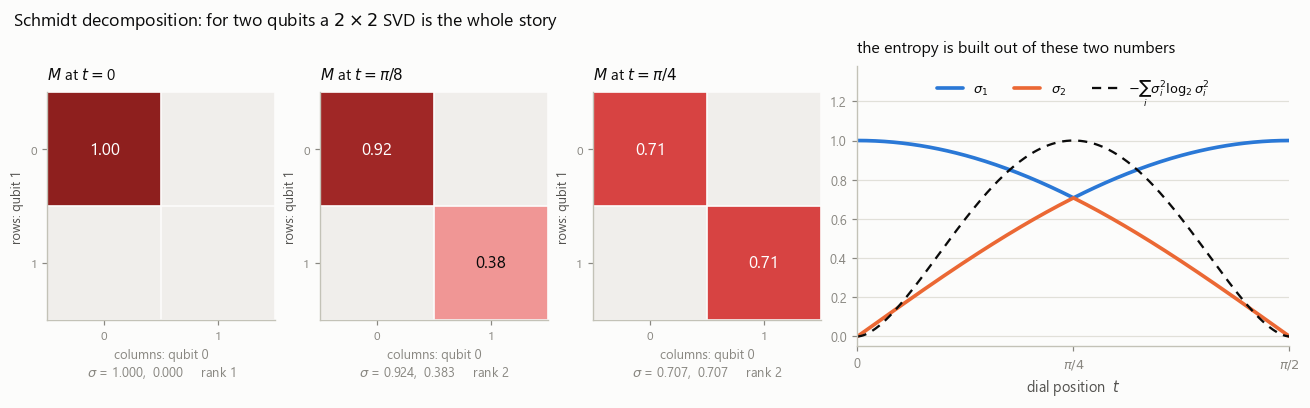

In [11]:
def schmidt_svd(vec):
    """Singular values of the 2x2 reshaping. Rows = qubit 1, cols = qubit 0."""
    return np.linalg.svd(np.asarray(vec).reshape(2, 2), compute_uv=False)


t_demo = [0.0, np.pi / 8, np.pi / 4]
t_demo_lab = ["0", r"$\pi/8$", r"$\pi/4$"]

sv_mid = Statevector(dial_circuit(np.pi / 8))
sd = schmidt_decomposition(sv_mid, [0])       # [0] = the qubit we factor against
print("schmidt_decomposition coefficients:",
      [round(float(c), 6) for c, _, _ in sd])
print("np.linalg.svd singular values     :",
      [round(float(s), 6) for s in schmidt_svd(sv_mid.data)])

lam = schmidt_svd(sv_mid.data) ** 2
lam = lam[lam > 1e-15]
print("\nentropy from the Schmidt coefficients:",
      round(float(-np.sum(lam * np.log2(lam))), 6))
print("entropy from qiskit                 :",
      round(entropy(partial_trace(sv_mid, [1])), 6))
print("\neigenvalues of rho_0:",
      np.round(np.linalg.eigvalsh(partial_trace(sv_mid, [1]).data), 6),
      "   sigma_i^2:", np.round(np.sort(schmidt_svd(sv_mid.data) ** 2), 6))

sig1 = np.array([schmidt_svd(Statevector(dial_circuit(t)).data)[0] for t in ts])
sig2 = np.array([schmidt_svd(Statevector(dial_circuit(t)).data)[1] for t in ts])

fig = plt.figure(figsize=(11.8, 3.6))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.9])

for k, t in enumerate(t_demo):
    ax = fig.add_subplot(gs[0, k])
    M = Statevector(dial_circuit(t)).data.reshape(2, 2)
    grid.matrix(ax, M, part="re", cbar=False, annot_size=11,
                labels=["0", "1"], vmax=1.0,
                title=f"$M$ at $t = ${t_demo_lab[k]}")
    s = schmidt_svd(M.ravel())
    ax.set_xlabel(f"columns: qubit 0\n$\\sigma$ = {s[0]:.3f},  {s[1]:.3f}"
                  f"     rank {int(np.sum(s > 1e-9))}",
                  fontsize=8.5, color=style.MUTED)
    ax.set_ylabel("rows: qubit 1", fontsize=8.5)

axs = fig.add_subplot(gs[0, 3])
axs.plot(ts, sig1, color=style.BLUE, lw=2.4, label=r"$\sigma_1$")
axs.plot(ts, sig2, color=style.ORANGE, lw=2.4, label=r"$\sigma_2$")
axs.plot(ts, S0, color=style.INK, lw=1.5, ls=(0, (4, 3)),
         label=r"$-\sum_i\sigma_i^2\log_2\sigma_i^2$")
axs.set_xlim(0, np.pi / 2)
axs.set_ylim(-0.05, 1.38)
axs.set_xticks([0, np.pi / 4, np.pi / 2])
axs.set_xticklabels(["0", r"$\pi/4$", r"$\pi/2$"])
axs.set_xlabel(r"dial position  $t$")
axs.legend(loc="upper center", ncols=3, fontsize=8.5)
axs.set_title("the entropy is built out of these two numbers", loc="left",
              fontsize=10.5)

fig.suptitle(r"Schmidt decomposition: for two qubits a $2\times2$ SVD is the "
             r"whole story", x=0.005, ha="left", fontsize=11.5)
plt.show()

The three matrix panels are A06's rank test with a magnitude attached. At $t=0$
the matrix is rank 1 and $\sigma_2 = 0$: a product state. At $t=\pi/4$ both
singular values are $1/\sqrt2$: maximally entangled. In between the rank is
*also* 2, which is exactly why a rank test alone is not enough —
$\sigma_2 = 0.38$ and $\sigma_2 = 0.707$ are both "entangled" and are nowhere
near the same amount.

The Schmidt picture also explains why this notebook stays at two qubits. For a
bipartition of $n$ qubits into two halves the same SVD works, and the number of
Schmidt coefficients is $2^{\min(k,\,n-k)}$ — which is precisely the bond
dimension a matrix-product state must carry. Low-entanglement circuits are
classically simulable because that number stays small; high-entanglement ones are
not because it does not. C30 returns to this.

## Honest limits — the dial lies about mixed states

Everything above is true for **pure** global states, and that qualifier is not a
footnote. It is the difference between a valid measure and a broken one.

**The claim that breaks.** "The entropy of the reduced state measures
entanglement" is a theorem *only if the global state is pure*. The reasoning
behind it is: the pair has zero entropy, the part has positive entropy, so the
missing information must be stored in the correlation. Once the pair itself is
uncertain — a mixed $\rho$, which is what any real device hands you — a qubit's
reduced entropy can come from **ordinary classical ignorance** instead, and the
measure cannot tell the two sources apart.

**A state that scores a perfect 1.000 bit and contains no entanglement.** Take

$$\rho_{\text{classical}} = \tfrac12|00\rangle\langle00| + \tfrac12|11\rangle\langle11|.$$

Flip a fair coin, write the answer on two cards, seal them in envelopes. Both
reduced states are $I/2$, so the reduced entropy is exactly 1 bit — the same
score $|\Phi^+\rangle$ gets. Measure both in the $Z$ basis and you get the
*identical* counts figure to the one above: `00` and `11`, fifty-fifty, never
`01` or `10`. There is no entanglement anywhere in it. The only difference from
$|\Phi^+\rangle$ is those two off-diagonal corners.

**The Werner family makes it systematic.** Mix $|\Phi^+\rangle$ with white noise:

$$\rho(p) = p\,|\Phi^+\rangle\langle\Phi^+| + (1-p)\,\tfrac{I}{4}.$$

The reduced state is $I/2$ for *every* $p$, so reduced entropy reads 1.000 bit
all the way down to $p=0$, which is pure noise. Concurrence — which is properly
defined for mixed states, via Wootters' formula — correctly reports zero until
$p = 1/3$, and only then starts to climb.

The left panel below contains a flat line that is confidently and uselessly wrong
across the entire plot.

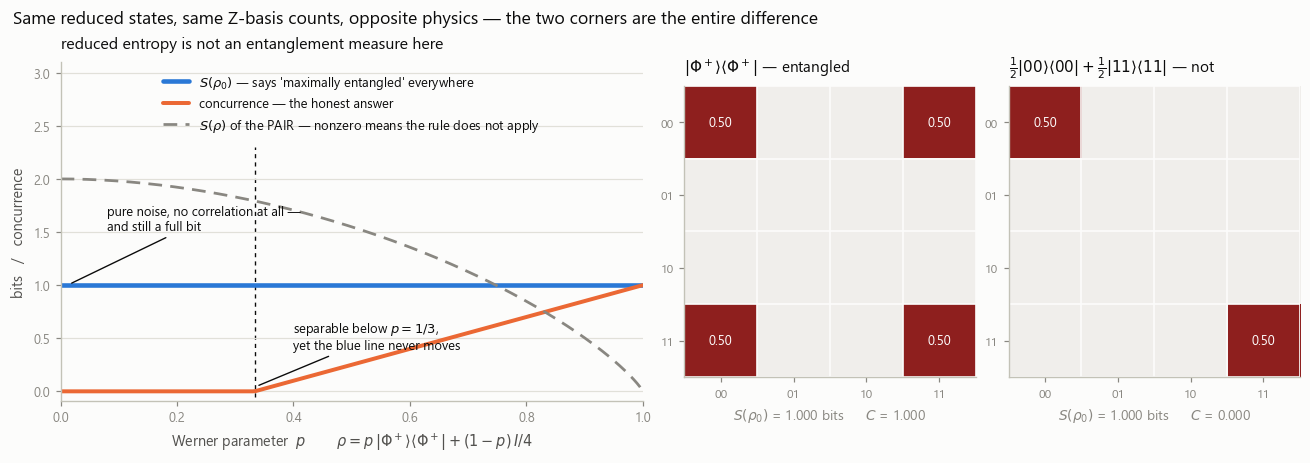

classical mixture:  S(rho_0) = 1.0   concurrence = 0.0
Bell state       :  S(rho_0) = 1.0   concurrence = 1.0


In [12]:
rho_bell = DensityMatrix(phi_plus).data
rho_classical = DensityMatrix(np.diag([0.5, 0.0, 0.0, 0.5]).astype(complex))

ps = np.linspace(0.0, 1.0, 201)
S_red = np.empty_like(ps)
C_mix = np.empty_like(ps)
S_glob = np.empty_like(ps)
for i, p in enumerate(ps):
    w = DensityMatrix(p * rho_bell + (1 - p) * np.eye(4) / 4)
    S_red[i] = entropy(partial_trace(w, [1]))
    C_mix[i] = concurrence(w)
    S_glob[i] = entropy(w)

fig = plt.figure(figsize=(11.8, 4.1))
gs = fig.add_gridspec(1, 3, width_ratios=[2.0, 1, 1])

ax = fig.add_subplot(gs[0, 0])
ax.plot(ps, S_red, color=style.BLUE, lw=3.0,
        label=r"$S(\rho_0)$ — says 'maximally entangled' everywhere")
ax.plot(ps, C_mix, color=style.ORANGE, lw=2.6,
        label="concurrence — the honest answer")
ax.plot(ps, S_glob, color=style.MUTED, lw=1.8, ls=(0, (5, 3)),
        label=r"$S(\rho)$ of the PAIR — nonzero means the rule does not apply")
ax.plot([1 / 3] * 2, [-0.05, 2.30], color=style.INK, lw=0.9, ls=(0, (3, 3)),
        zorder=1)                    # stops short of the legend box
ax.set_xlim(0, 1)
ax.set_ylim(-0.09, 3.10)
ax.set_xlabel(r"Werner parameter  $p$        "
              r"$\rho = p\,|\Phi^+\rangle\langle\Phi^+| + (1-p)\,I/4$")
ax.set_ylabel("bits   /   concurrence")
ax.legend(loc="upper center", fontsize=8.5)
ax.set_title("reduced entropy is not an entanglement measure here",
             loc="left", fontsize=10.5)
grid.annotate(ax, "separable below $p = 1/3$,\nyet the blue line never moves",
              xy=(1 / 3, 0.04), xytext=(0.40, 0.52), color=style.INK)
grid.annotate(ax, "pure noise, no correlation at all —\nand still a full bit",
              xy=(0.012, 1.0), xytext=(0.08, 1.62), color=style.INK)

for k, (rr, ttl) in enumerate([
        (rho_bell, r"$|\Phi^+\rangle\langle\Phi^+|$ — entangled"),
        (rho_classical.data,
         r"$\frac{1}{2}|00\rangle\langle00| + "
         r"\frac{1}{2}|11\rangle\langle11|$ — not")]):
    axm = fig.add_subplot(gs[0, k + 1])
    grid.matrix(axm, rr, part="re", cbar=False, annot_size=8.5, vmax=0.5,
                title=ttl)
    s_red = entropy(partial_trace(DensityMatrix(rr), [1]))
    c_val = concurrence(DensityMatrix(rr))
    axm.set_xlabel(f"$S(\\rho_0)$ = {s_red:.3f} bits      $C$ = {c_val:.3f}",
                   fontsize=9, color=style.MUTED)

fig.suptitle("Same reduced states, same Z-basis counts, opposite physics — "
             "the two corners are the entire difference",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print("classical mixture:  S(rho_0) =",
      round(entropy(partial_trace(rho_classical, [1])), 6),
      "  concurrence =", round(concurrence(rho_classical), 6))
print("Bell state       :  S(rho_0) =",
      round(entropy(partial_trace(DensityMatrix(rho_bell), [1])), 6),
      "  concurrence =", round(concurrence(DensityMatrix(rho_bell)), 6))

### The rest of the fine print

**Concurrence is a two-qubit convenience, and only that.** Wootters' formula is a
closed-form miracle that exists for $2\times2$ systems and essentially nowhere
else. For a qubit–qutrit pair, for three qubits, for anything larger, there is no
single number playing this role: entanglement of formation becomes a hard
optimisation, and for mixed states of dimension $\ge 2\times4$ even *deciding*
separability is NP-hard. Do not build an intuition that assumes a scalar
"amount of entanglement" always exists. Usually it does not.

**Detecting mixed-state entanglement needs different tools.** The
Peres–Horodecki (PPT) criterion — partial-transpose one subsystem and look for a
negative eigenvalue — is necessary *and* sufficient for $2\times2$ and
$2\times3$, and necessary only above that: bound entangled states exist which are
PPT and still entangled. A12 and B26 are where mixed states become the subject.

**Multipartite entanglement is not one thing.** With three qubits, GHZ and W
states are both "entangled", cannot be converted into one another by local
operations, and behave completely differently when you lose a qubit. "How
entangled is this state" stops being a well-posed question.

**Everything here ran on an ideal simulator.** No decoherence, no gate error, no
readout error. On hardware, `01` and `10` *do* appear in that counts figure at
the percent level, and the concurrence of the state you actually prepared is
noticeably below 1. B19 measures how far a realistic Bell state can push a CHSH
value; B26 does the noise properly.

**`Statevector` is a $2^n$ object and `DensityMatrix` a $4^n$ one.** The dial
cost 241 two-qubit simulations, which is nothing. The same sweep on 20 qubits is
not a slower version of this notebook, it is a different problem — A07 measures
the wall.

## Checkpoint

Track B notebooks close by asserting against the Track A result they mirror. B18
mirrors **A06**: the same little-endian CNOT, built from projectors with `op_on`,
must reproduce Qiskit's statevector exactly — and the partial trace we wrote out
index by index must reproduce `qiskit.quantum_info.partial_trace`.

In [13]:
# --- A06's machinery, transcribed ----------------------------------------
I2 = np.eye(2, dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
P0 = np.array([[1, 0], [0, 0]], dtype=complex)
P1 = np.array([[0, 0], [0, 1]], dtype=complex)


def op_on(U, k, n):
    """A06's helper: place U on qubit k. Little-endian, so the loop runs n-1..0."""
    out = np.array([[1.0 + 0j]])
    for j in range(n - 1, -1, -1):
        out = np.kron(out, U if j == k else I2)
    return out


def controlled(U, control, target, n=2):
    """A06's projector form:  |0><0|_c (x) I  +  |1><1|_c (x) U_t."""
    return op_on(P0, control, n) + op_on(P1, control, n) @ op_on(U, target, n)


CNOT_01 = controlled(X, control=0, target=1)
assert np.allclose(CNOT_01, [[1, 0, 0, 0], [0, 0, 0, 1],
                             [0, 0, 1, 0], [0, 1, 0, 0]])   # A06's hand table

# 1. THE CROSS-TRACK ASSERTION: A06's construction == Qiskit, all four states.
ket00 = np.zeros(4, dtype=complex)
ket00[0] = 1.0
for (b1, b0) in inputs:
    prep = np.eye(4, dtype=complex)
    if b0:
        prep = op_on(X, 0, 2) @ prep
    if b1:
        prep = op_on(X, 1, 2) @ prep
    by_hand = CNOT_01 @ op_on(H, 0, 2) @ prep @ ket00
    assert np.allclose(by_hand, BELL[(b1, b0)].data), (b1, b0)
    assert np.allclose(by_hand, Statevector(bell_circuit(b1, b0)).data)

# 2. The from-scratch partial trace agrees with Qiskit's, on random states.
for _ in range(50):
    v = rng.normal(size=4) + 1j * rng.normal(size=4)
    v /= np.linalg.norm(v)
    r = np.outer(v, v.conj())
    assert np.allclose(my_partial_trace(r, keep=[0]),
                       partial_trace(Statevector(v), [1]).data)
    assert np.allclose(my_partial_trace(r, keep=[1]),
                       partial_trace(Statevector(v), [0]).data)
# ...and qargs really is "throw these away": tracing out qubit 1 of |01> must
# leave qubit 0 in |1>, not |0>.
assert np.allclose(partial_trace(Statevector.from_label("01"), [1]).data,
                   [[0, 0], [0, 1]])

# 3. The four Bell states are an orthonormal basis.
assert np.allclose(B.conj().T @ B, np.eye(4))

# 4. Every Bell state: both halves maximally mixed, 1 bit of entropy, C = 1.
for key in inputs:
    st = BELL[key]
    assert np.isclose(float(partial_trace(st, [1]).purity().real), 0.5)
    assert np.isclose(entropy(partial_trace(st, [1])), 1.0)
    assert np.isclose(entropy(partial_trace(st, [0])), 1.0)
    assert np.isclose(concurrence(st), 1.0)
    assert np.linalg.norm(bloch_vector(partial_trace(st, [1]).data)) < 1e-12

# 5. THE DIAL, as exact identities rather than as curves.
assert np.allclose(C, np.abs(np.sin(2 * ts)), atol=1e-9)      # concurrence
assert np.allclose(R0, np.abs(np.cos(2 * ts)), atol=1e-9)     # Bloch length
assert np.allclose(R0 ** 2 + C ** 2, 1.0, atol=1e-9)          # the exact trade
assert np.allclose(R0, R1, atol=1e-9)
assert np.allclose(S0, S1, atol=1e-9)             # both qubits, always equal
assert np.isclose(S0.max(), 1.0, atol=1e-6) and S0.max() <= 1.0 + 1e-9

# 6. Entropy really is the Shannon entropy of the Schmidt coefficients.
for t in [0.3, 0.7, np.pi / 4, 1.2]:
    lam = schmidt_svd(Statevector(dial_circuit(t)).data) ** 2
    lam = lam[lam > 1e-15]
    assert np.isclose(-np.sum(lam * np.log2(lam)),
                      entropy(partial_trace(Statevector(dial_circuit(t)), [1])))

# 7. Correlations: <ZZ> = 1 everywhere; <XX> = C; <Z_0>^2 + <XX>^2 = 1.
assert np.allclose(ZZ, 1.0, atol=1e-9)
assert np.allclose(XX, C, atol=1e-9)
assert np.allclose(Z0 ** 2 + XX ** 2, 1.0, atol=1e-9)

# 8. Sampling: the forbidden outcomes are forbidden; the marginals are fair.
assert counts.get("01", 0) == 0 and counts.get("10", 0) == 0
assert int(np.sum(q0 != q1)) == 0
assert np.abs(marg0 - 0.5).max() < 5 * np.sqrt(0.25 / SHOTS)
assert np.abs(marg1 - 0.5).max() < 5 * np.sqrt(0.25 / SHOTS)

# 9. The honest limit, asserted: a full bit of reduced entropy, zero entanglement.
assert np.isclose(entropy(partial_trace(rho_classical, [1])), 1.0)
assert np.isclose(concurrence(rho_classical), 0.0, atol=1e-9)
assert np.allclose(S_red, 1.0, atol=1e-9)                     # flat for every p
assert np.allclose(C_mix[ps <= 1 / 3], 0.0, atol=1e-9)        # separable there
assert np.allclose(C_mix[ps > 1 / 3],
                   (3 * ps[ps > 1 / 3] - 1) / 2, atol=1e-9)   # Wootters

print("B18 checkpoint passed.")

B18 checkpoint passed.


---

**Next:** [B19 — Bell Inequalities and CHSH](B19_Bell_Inequalities_CHSH.ipynb).
This notebook showed that entanglement is real *inside the formalism*. B19 asks
the harder question — whether any story about answers agreed in advance could
reproduce these correlations — and settles it with a number that no classical
account can reach.